In [60]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn.functional as F
from tqdm import tqdm

warnings.filterwarnings("ignore")

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: cuda


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks"

TOXIC_IMG_DIR = os.path.join(DATA_DIR, "tpc-imgs/toxic_images")
NONTOXIC_IMG_DIR = os.path.join(DATA_DIR, "tpc-imgs/nontoxic_images")

FULL_METADATA_PATH = os.path.join(DATA_DIR, "tpc-imgs/full_metadata.csv")
TOXIC_METADATA_PATH = os.path.join(DATA_DIR, "tpc-imgs/toxic_metadata.csv")
NONTOXIC_METADATA_PATH = os.path.join(DATA_DIR, "tpc-imgs/nontoxic_metadata.csv")

# Image / loader settings
IMG_SIZE = 260
BATCH_SIZE = 16
NUM_WORKERS = 0 if str(device) == "mps" else 2
PIN_MEMORY = True if str(device) == "cuda" else False

# Training phases
STAGE1_EPOCHS = 10
STAGE2_EPOCHS = 20
STAGE1_LR = 1e-4
STAGE2_LR = 1e-5

# Regularization / stopping
WEIGHT_DECAY = 1e-3
EARLY_STOPPING_PATIENCE = 4

# Saving
BEST_MODEL_PATH = "best_efficientnet_b2_stage1.pth"
FINAL_MODEL_PATH = "best_efficientnet_b2_stage2.pth"

# Classes (training = 2 classes )
CLASS_NAMES = ["Non-Toxic", "Toxic"]

# Unknown label ( inference )
UNKNOWN_LABEL = "Unknown"

print("DATA_DIR:", DATA_DIR)
print("TOXIC_IMG_DIR exists:", os.path.exists(TOXIC_IMG_DIR))
print("NONTOXIC_IMG_DIR exists:", os.path.exists(NONTOXIC_IMG_DIR))
print("FULL_METADATA_PATH exists:", os.path.exists(FULL_METADATA_PATH))

DATA_DIR: /content/drive/MyDrive/Colab Notebooks
TOXIC_IMG_DIR exists: True
NONTOXIC_IMG_DIR exists: True
FULL_METADATA_PATH exists: True


In [64]:
def load_and_clean_metadata(csv_path):
    df = pd.read_csv(csv_path)

    def build_lookup(img_dir):
        lookup = {}
        for root, _, files in os.walk(img_dir):
            for f in files:
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                    lookup[f.lower()] = os.path.join(root, f)
        return lookup

    toxic_files = build_lookup(TOXIC_IMG_DIR)
    nontoxic_files = build_lookup(NONTOXIC_IMG_DIR)

    valid_rows = []
    abs_paths = []

    for idx, row in df.iterrows():
        csv_filename = os.path.basename(row["path"]).lower()

        if row["toxicity"] == 1 and csv_filename in toxic_files:
            valid_rows.append(idx)
            abs_paths.append(toxic_files[csv_filename])

        elif row["toxicity"] == 0 and csv_filename in nontoxic_files:
            valid_rows.append(idx)
            abs_paths.append(nontoxic_files[csv_filename])

    df_clean = df.loc[valid_rows].copy().reset_index(drop=True)
    df_clean["abs_path"] = abs_paths

    return df_clean

In [65]:
print(FULL_METADATA_PATH)
print(os.path.exists(FULL_METADATA_PATH))

/content/drive/MyDrive/Colab Notebooks/tpc-imgs/full_metadata.csv
True


In [66]:
df = load_and_clean_metadata(FULL_METADATA_PATH)

print("Columns:")
print(df.columns.tolist())

print("\nDataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nToxicity counts:")
print(df["toxicity"].value_counts().sort_index())

print("\nMissing values:")
print(df.isnull().sum())

Columns:
['class_id', 'slang', 'scientific_name', 'herbarium22_category_id', 'path', 'toxicity', 'species_label', 'abs_path']

Dataset shape: (9952, 8)

First 5 rows:


,class_id,slang,scientific_name,herbarium22_category_id,path,toxicity,species_label,abs_path
0,0,Virginia creeper,Parthenocissus quinquefolia,10340,../input/toxic-plant-classification/tpc-imgs/n...,0,3,/content/drive/MyDrive/Colab Notebooks/tpc-img...
1,0,Virginia creeper,Parthenocissus quinquefolia,10340,../input/toxic-plant-classification/tpc-imgs/n...,0,3,/content/drive/MyDrive/Colab Notebooks/tpc-img...
2,0,Virginia creeper,Parthenocissus quinquefolia,10340,../input/toxic-plant-classification/tpc-imgs/n...,0,3,/content/drive/MyDrive/Colab Notebooks/tpc-img...
3,0,Virginia creeper,Parthenocissus quinquefolia,10340,../input/toxic-plant-classification/tpc-imgs/n...,0,3,/content/drive/MyDrive/Colab Notebooks/tpc-img...
4,0,Virginia creeper,Parthenocissus quinquefolia,10340,../input/toxic-plant-classification/tpc-imgs/n...,0,3,/content/drive/MyDrive/Colab Notebooks/tpc-img...



Toxicity counts:
toxicity
0    4999
1    4953
Name: count, dtype: int64

Missing values:
class_id                   0
slang                      0
scientific_name            0
herbarium22_category_id    0
path                       0
toxicity                   0
species_label              0
abs_path                   0
dtype: int64


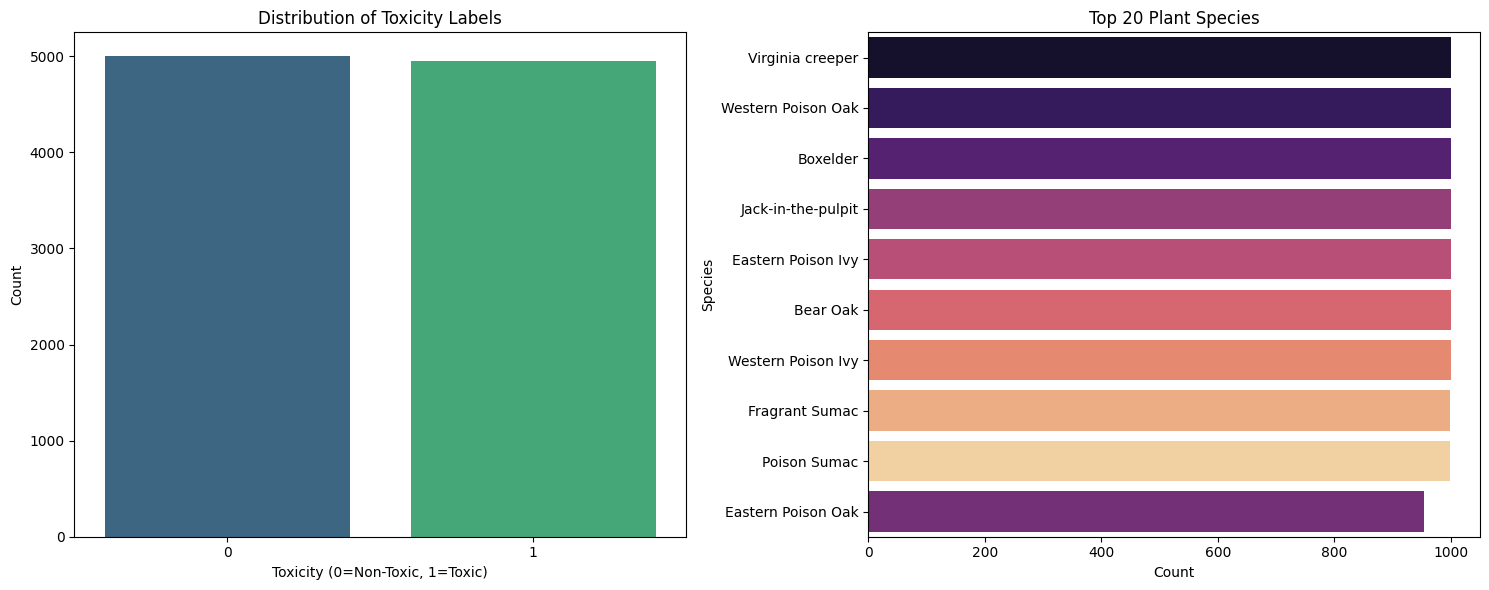

Top species counts:
slang
Virginia creeper      1000
Western Poison Oak    1000
Boxelder              1000
Jack-in-the-pulpit    1000
Eastern Poison Ivy    1000
Bear Oak              1000
Western Poison Ivy    1000
Fragrant Sumac         999
Poison Sumac           999
Eastern Poison Oak     954
Name: count, dtype: int64


In [67]:
plt.figure(figsize=(15, 6))

# Toxicity distribution
plt.subplot(1, 2, 1)
sns.countplot(data=df, x="toxicity", hue="toxicity", palette="viridis", legend=False)
plt.title("Distribution of Toxicity Labels")
plt.xlabel("Toxicity (0=Non-Toxic, 1=Toxic)")
plt.ylabel("Count")

# Top species
plt.subplot(1, 2, 2)
top_n = 20
top_species = df["slang"].value_counts().head(top_n).index
sns.countplot(
    data=df[df["slang"].isin(top_species)],
    y="slang",
    order=top_species,
    hue="slang",
    palette="magma",
    legend=False
)
plt.title(f"Top {top_n} Plant Species")
plt.xlabel("Count")
plt.ylabel("Species")

plt.tight_layout()
plt.show()

print("Top species counts:")
print(df["slang"].value_counts().head(top_n))

In [68]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["toxicity"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["toxicity"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (6966, 8)
Validation shape: (1493, 8)
Test shape: (1493, 8)


,Train,Validation,Test
Non-Toxic,3499,750,750
Toxic,3467,743,743


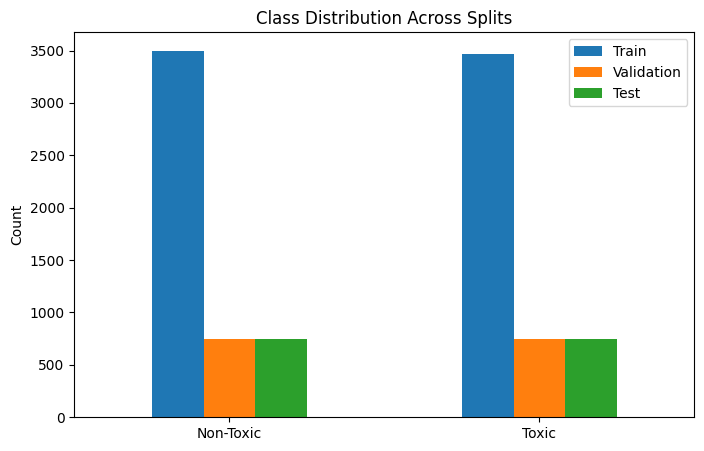

In [69]:
split_counts = pd.DataFrame({
    "Train": train_df["toxicity"].value_counts().sort_index(),
    "Validation": val_df["toxicity"].value_counts().sort_index(),
    "Test": test_df["toxicity"].value_counts().sort_index()
}).fillna(0).astype(int)

split_counts.index = ["Non-Toxic", "Toxic"]
display(split_counts)

split_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Class Distribution Across Splits")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [70]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(25),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), shear=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3))
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

In [71]:
class PoisonousPlantDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["abs_path"]).convert("RGB")
        label = int(row["toxicity"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [72]:
train_dataset = PoisonousPlantDataset(train_df, transform=train_transform)
val_dataset = PoisonousPlantDataset(val_df, transform=eval_transform)
test_dataset = PoisonousPlantDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images: {len(test_dataset)}")

Training images: 6966
Validation images: 1493
Test images: 1493


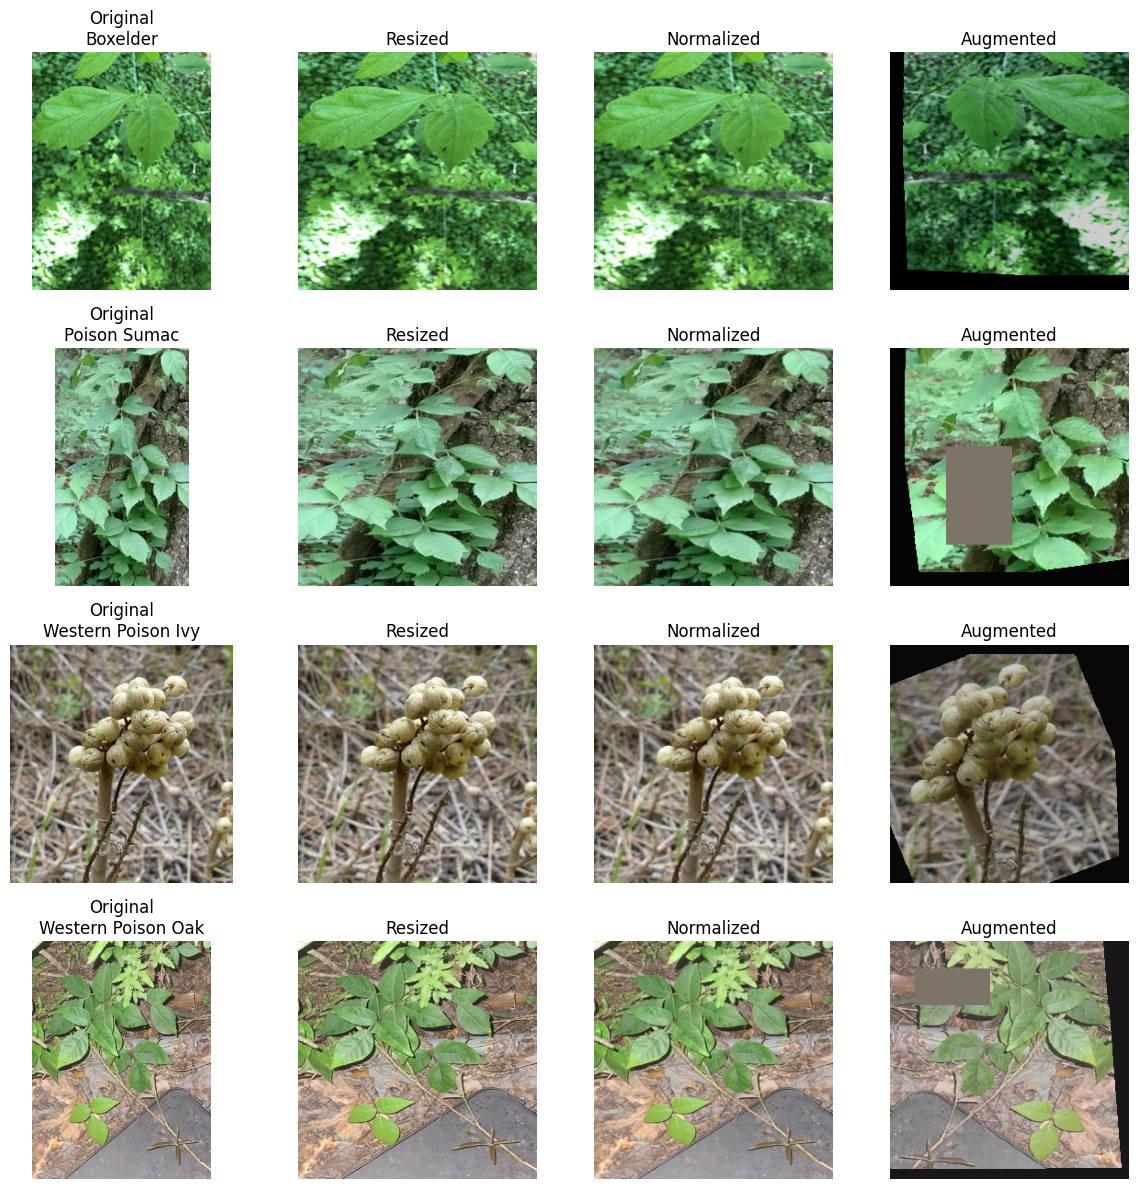

In [ ]:
def denormalize_image(img_tensor):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(imagenet_std) + np.array(imagenet_mean)
    img = np.clip(img, 0, 1)
    return img

def show_augmentation_samples(dataframe, n=4):
    sample_df = dataframe.sample(n=n, random_state=42).reset_index(drop=True)

    plt.figure(figsize=(12, 3 * n))

    for i in range(n):
        img_path = sample_df.loc[i, "abs_path"]
        label = sample_df.loc[i, "toxicity"]
        species = sample_df.loc[i, "slang"]  

        original = Image.open(img_path).convert("RGB")
        resized = original.resize((IMG_SIZE, IMG_SIZE))
        normalized = eval_transform(original)
        augmented = train_transform(original)

        images = [
            np.array(original),
            np.array(resized),
            denormalize_image(normalized),
            denormalize_image(augmented)
        ]

        titles = [
            f"Original\n{species}",
            "Resized",
            "Normalized",
            "Augmented"
        ]

        for j in range(4):
            plt.subplot(n, 4, i * 4 + j + 1)
            plt.imshow(images[j])
            plt.title(titles[j])
            plt.axis("off")

    plt.tight_layout()
    plt.show()

show_augmentation_samples(df, n=4)

In [74]:
weights = models.EfficientNet_B2_Weights.IMAGENET1K_V1
model = models.efficientnet_b2(weights=weights)

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_features, 512),
    nn.SiLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(p=0.3),
    nn.Linear(512, 2)
)

model = model.to(device)

print("EfficientNet-B2 loaded.")

EfficientNet-B2 loaded.


In [75]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer_stage1 = optim.AdamW(
    model.classifier.parameters(),
    lr=STAGE1_LR,
    weight_decay=WEIGHT_DECAY
)

scheduler_stage1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage1,
    mode="min",
    factor=0.5,
    patience=1
)

print("Stage 1 setup complete.")

Stage 1 setup complete.


In [76]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs, patience, model_save_path, scheduler=None):
    best_val_loss = float("inf")
    patience_counter = 0

    train_loss_history, val_loss_history = [], []
    train_acc_history, val_acc_history = [], []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            dataloader = dataloaders[phase]
            pbar = tqdm(dataloader, desc=f"{phase.capitalize()}")

            for inputs, labels in pbar:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                pbar.set_postfix({"loss": f"{loss.item():.4f}"})

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.float() / len(dataloader.dataset)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == "train":
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.item())
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.item())

                if scheduler is not None:
                    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                        scheduler.step(epoch_loss)
                    else:
                        scheduler.step()

                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    patience_counter = 0
                    torch.save(model.state_dict(), model_save_path)
                    print("--> New best model saved!")
                else:
                    patience_counter += 1
                    print(f"--> No improvement in validation loss for {patience_counter} epoch(s).")

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

        print()

    return {
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "train_acc": train_acc_history,
        "val_acc": val_acc_history
    }

In [77]:
dataloaders = {"train": train_loader, "val": val_loader}

print("STAGE 1: Training")
history_stage1 = train_model(
    model=model,
    dataloaders=dataloaders,
    criterion=criterion,
    optimizer=optimizer_stage1,
    num_epochs=STAGE1_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    model_save_path=BEST_MODEL_PATH,
    scheduler=scheduler_stage1
)

STAGE 1: Training
Epoch 1/10
----------


Train: 100%|██████████| 436/436 [01:58<00:00,  3.69it/s, loss=0.5339]


Train Loss: 0.5389 Acc: 0.7357


Val: 100%|██████████| 94/94 [00:13<00:00,  7.12it/s, loss=0.8037]


Val Loss: 0.4094 Acc: 0.8178
--> New best model saved!

Epoch 2/10
----------


...

Val Loss: 0.3718 Acc: 0.8305
--> New best model saved!

Epoch 10/10
----------


Train: 100%|██████████| 436/436 [01:50<00:00,  3.93it/s, loss=0.5216]


Train Loss: 0.4422 Acc: 0.7969


Val: 100%|██████████| 94/94 [00:13<00:00,  7.06it/s, loss=0.8216]

Val Loss: 0.3832 Acc: 0.8245
--> No improvement in validation loss for 1 epoch(s).



In [78]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze classifier
for param in model.classifier.parameters():
    param.requires_grad = True

# Unfreeze only last 2 feature blocks
for param in model.features[-2:].parameters():
    param.requires_grad = True

optimizer_stage2 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=STAGE2_LR,
    weight_decay=WEIGHT_DECAY
)

scheduler_stage2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage2,
    mode="min",
    factor=0.5,
    patience=1
)

print("Stage 2 setup complete.")

Stage 2 setup complete.


In [79]:
print("STAGE 2: Fine-Tuning")
history_stage2 = train_model(
    model=model,
    dataloaders=dataloaders,
    criterion=criterion,
    optimizer=optimizer_stage2,
    num_epochs=STAGE2_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    model_save_path=FINAL_MODEL_PATH,
    scheduler=scheduler_stage2
)

STAGE 2: Fine-Tuning
Epoch 1/20
----------


Train: 100%|██████████| 436/436 [01:54<00:00,  3.80it/s, loss=0.3982]


Train Loss: 0.4200 Acc: 0.8095


Val: 100%|██████████| 94/94 [00:13<00:00,  7.12it/s, loss=0.5820]


Val Loss: 0.3366 Acc: 0.8426
--> New best model saved!

Epoch 2/20
----------


...

Val Loss: 0.1316 Acc: 0.9538
--> New best model saved!

Epoch 20/20
----------


Train: 100%|██████████| 436/436 [01:54<00:00,  3.81it/s, loss=0.3313]


Train Loss: 0.2229 Acc: 0.9091


Val: 100%|██████████| 94/94 [00:12<00:00,  7.57it/s, loss=0.3663]


Val Loss: 0.1275 Acc: 0.9578
--> New best model saved!



In [80]:
def merge_histories(hist1, hist2):
    return {
        "train_loss": hist1["train_loss"] + hist2["train_loss"],
        "val_loss": hist1["val_loss"] + hist2["val_loss"],
        "train_acc": hist1["train_acc"] + hist2["train_acc"],
        "val_acc": hist1["val_acc"] + hist2["val_acc"]
    }

history = merge_histories(history_stage1, history_stage2)
split_epoch = len(history_stage1["train_loss"])
epochs = range(1, len(history["train_loss"]) + 1)

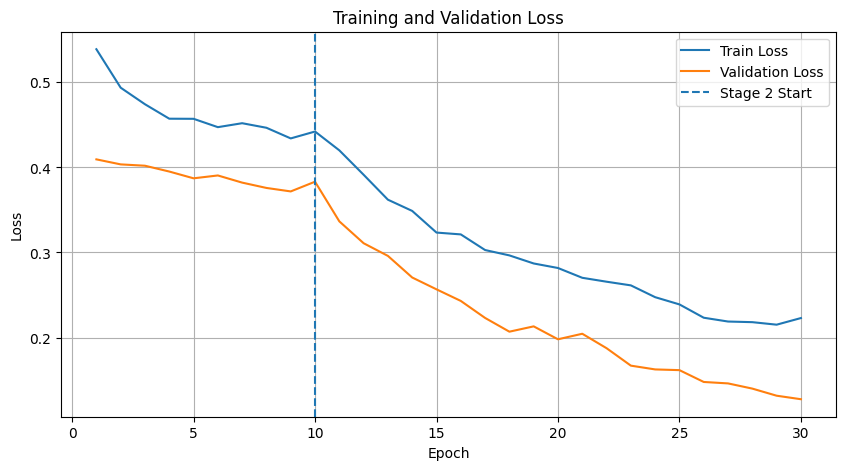

In [81]:
plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.axvline(split_epoch, linestyle="--", label="Stage 2 Start")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

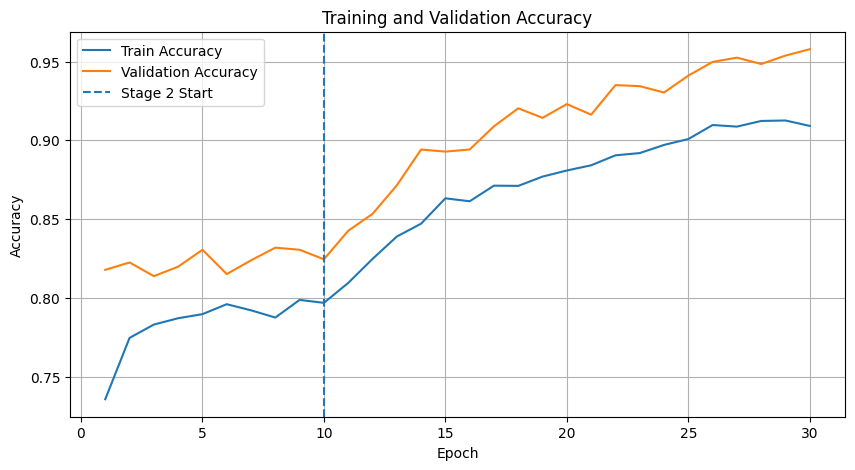

In [82]:
plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.axvline(split_epoch, linestyle="--", label="Stage 2 Start")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [83]:
best_model_path = FINAL_MODEL_PATH if os.path.exists(FINAL_MODEL_PATH) else BEST_MODEL_PATH
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

print("Loaded best model from:", best_model_path)

Loaded best model from: best_efficientnet_b2_stage2.pth


In [84]:
def get_all_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            # Move only inputs to device
            inputs = inputs.to(device, non_blocking=True)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            # Keep labels on CPU
            all_preds.extend(preds.cpu().numpy().astype(int).tolist())
            all_labels.extend(labels.numpy().astype(int).tolist())

    return all_preds, all_labels


In [85]:
val_preds, val_labels = get_all_predictions(model, val_loader, device)

val_preds = np.array(val_preds, dtype=int).flatten()
val_labels = np.array(val_labels, dtype=int).flatten()

print("Unique values in val_labels:", np.unique(val_labels))
print("Unique values in val_preds:", np.unique(val_preds))
print("Validation samples:", len(val_labels), len(val_preds))

val_acc = accuracy_score(val_labels, val_preds)

print(f"Validation Accuracy: {val_acc:.4f}")
print("\nValidation Classification Report:")
print(classification_report(
    val_labels,
    val_preds,
    labels=[0, 1],
    target_names=CLASS_NAMES,
    zero_division=0
))

Unique values in val_labels: [0 1]
Unique values in val_preds: [0 1]
Validation samples: 1493 1493
Validation Accuracy: 0.9578

Validation Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.97      0.95      0.96       750
       Toxic       0.95      0.97      0.96       743

    accuracy                           0.96      1493
   macro avg       0.96      0.96      0.96      1493
weighted avg       0.96      0.96      0.96      1493



In [86]:
test_preds, test_labels = get_all_predictions(model, test_loader, device)

test_preds = np.array(test_preds, dtype=int).flatten()
test_labels = np.array(test_labels, dtype=int).flatten()

print("Unique values in test_labels:", np.unique(test_labels))
print("Unique values in test_preds:", np.unique(test_preds))
print("Test samples:", len(test_labels), len(test_preds))

test_acc = accuracy_score(test_labels, test_preds)

print(f"Test Accuracy: {test_acc:.4f}")
print("\nTest Classification Report:")
print(classification_report(
    test_labels,
    test_preds,
    labels=[0, 1],
    target_names=CLASS_NAMES,
    zero_division=0
))

Unique values in test_labels: [0 1]
Unique values in test_preds: [0 1]
Test samples: 1493 1493
Test Accuracy: 0.9672

Test Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.98      0.95      0.97       750
       Toxic       0.95      0.98      0.97       743

    accuracy                           0.97      1493
   macro avg       0.97      0.97      0.97      1493
weighted avg       0.97      0.97      0.97      1493



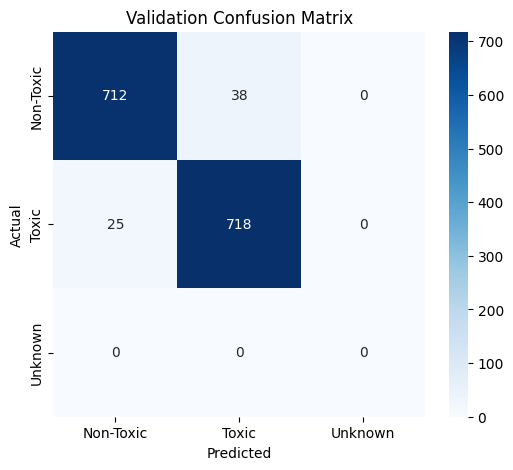

In [87]:
val_cm = confusion_matrix(val_labels, val_preds, labels=[0, 1])

cm_with_unknown = np.zeros((3, 3), dtype=int)
cm_with_unknown[:2, :2] = val_cm

CLASS_NAMES_WITH_UNKNOWN = ["Non-Toxic", "Toxic", "Unknown"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_with_unknown,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES_WITH_UNKNOWN,
    yticklabels=CLASS_NAMES_WITH_UNKNOWN
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")
plt.show()

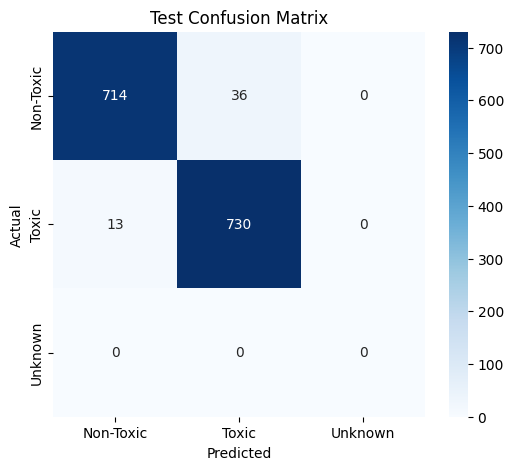

In [88]:
test_cm = confusion_matrix(test_labels, test_preds, labels=[0, 1])

cm_with_unknown = np.zeros((3, 3), dtype=int)

cm_with_unknown[:2, :2] = test_cm

CLASS_NAMES_WITH_UNKNOWN = ["Non-Toxic", "Toxic", "Unknown"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_with_unknown,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES_WITH_UNKNOWN,
    yticklabels=CLASS_NAMES_WITH_UNKNOWN
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Confusion Matrix")
plt.show()

In [89]:
IMG_SIZE = 224
BATCH_SIZE = 16

HIGH_CONF_THRESHOLD = 0.80
LOW_CONF_THRESHOLD = 0.60

CLASS_NAMES = [
    "Non-Toxic",
    "Toxic",
    "Unknown"
]

CLASS_INFO = {
    "Non-Toxic": {
        "color": "green",
        "advice": "This plant is safe."
    },
    "Toxic": {
        "color": "red",
        "advice": "⚠️ Stay away and call emergency if touched."
    },
    "Unknown": {
        "color": "orange",
        "advice": "⚠️ Not sure, avoid touching."
    }
}

In [93]:
def visualize_predictions(model, loader, device, class_names, num_images=10):
    model.eval()
    shown = 0

    plt.figure(figsize=(18, 12))

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predicting", leave=False):

            images = images.to(device)
            outputs = model(images)

            probs = F.softmax(outputs, dim=1).cpu()
            preds = torch.argmax(probs, dim=1)

            for i in range(images.size(0)):
                if shown >= num_images:
                    plt.tight_layout()
                    plt.show()
                    return


                img = images[i].cpu().numpy().transpose(1, 2, 0)
                img = img * np.array(imagenet_std) + np.array(imagenet_mean)
                img = np.clip(img, 0, 1)

                plt.subplot(2, 5, shown + 1)
                plt.imshow(img)


                prob_non_toxic = probs[i][0].item()
                prob_toxic = probs[i][1].item()
                confidence = max(prob_non_toxic, prob_toxic)

                if confidence < LOW_CONF_THRESHOLD:
                    label = "Unknown"
                else:
                    pred = preds[i].item()
                    label = class_names[pred]


                color = CLASS_INFO[label]["color"]
                advice = CLASS_INFO[label]["advice"]

                true_label = class_names[int(labels[i].item())]

                plt.title(
                    f"Pred: {label}\n"
                    f"True: {true_label}\n"
                    f"Toxic: {prob_toxic*100:.1f}%\n"
                    f"Conf: {confidence*100:.1f}%\n"
                    f"{advice}",
                    color=color,
                    fontsize=10
                )

                plt.axis("off")
                shown += 1

    plt.tight_layout()
    plt.show()


Predicting:   0%|          | 0/94 [00:00<?, ?it/s]

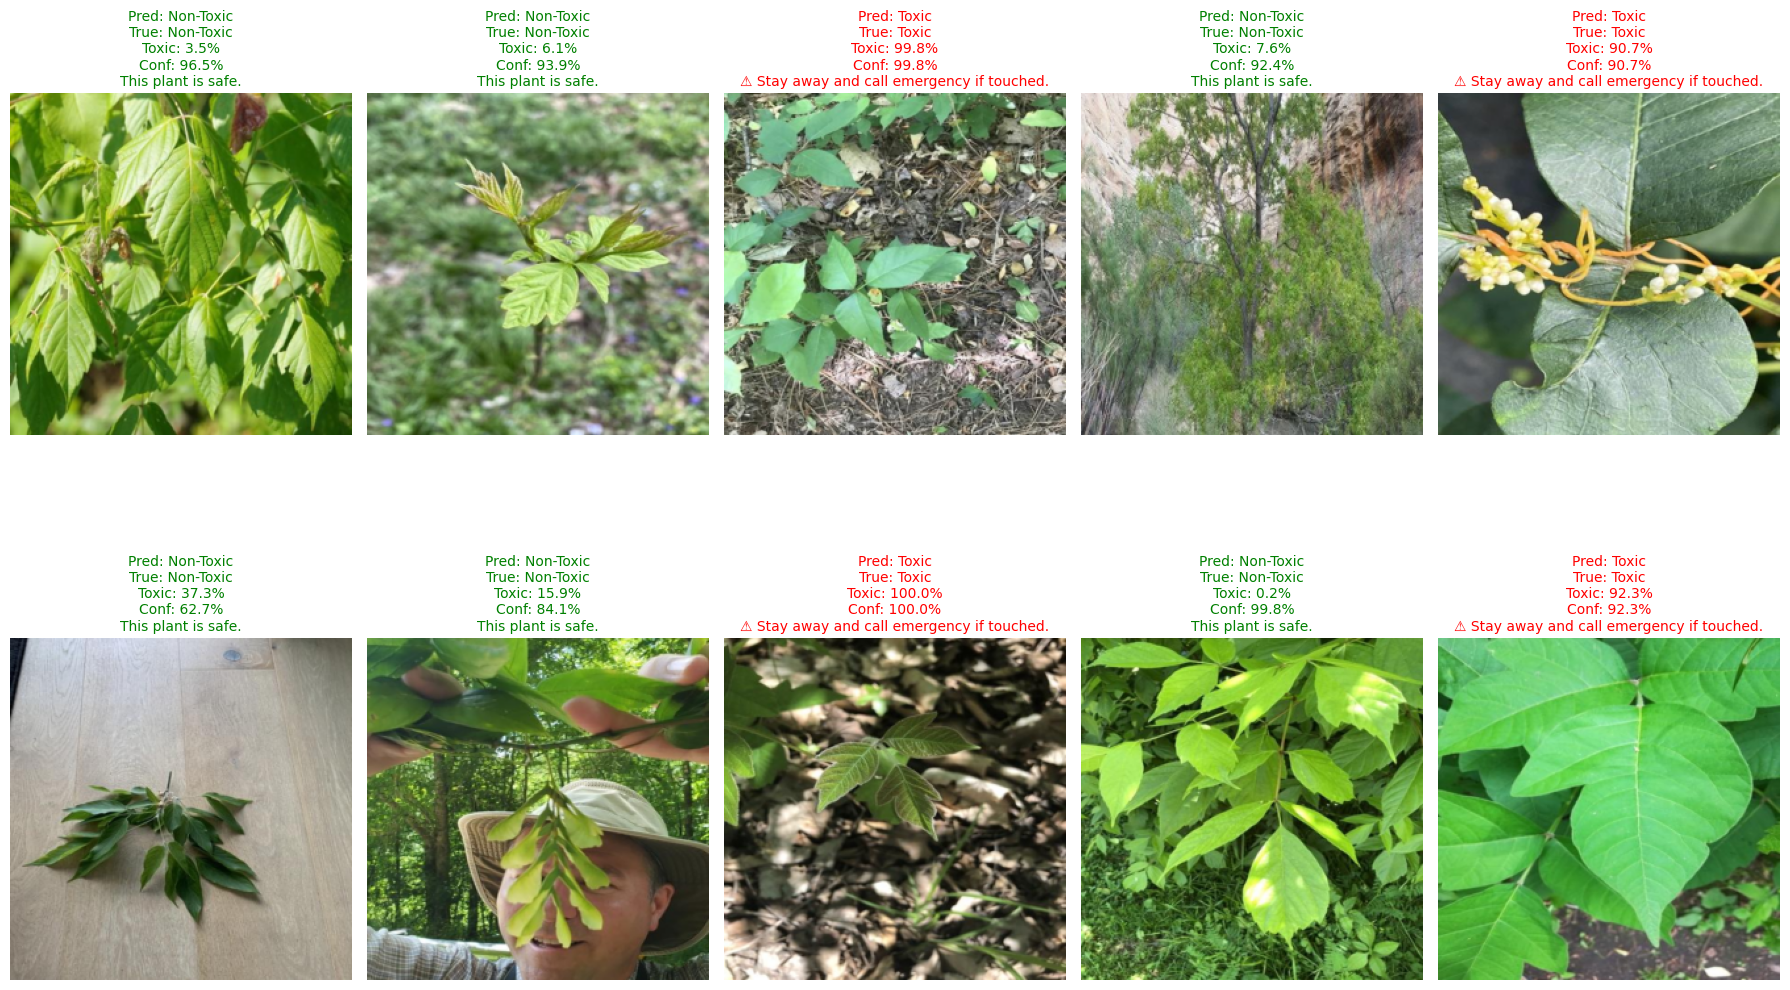

In [94]:
visualize_predictions(
    model=model,
    loader=test_loader,
    device=device,
    class_names=CLASS_NAMES,
    num_images=10
)

In [111]:
def format_prediction(probs):
    prob_non_toxic = probs[0][0].item() * 100
    prob_toxic = probs[0][1].item() * 100

    HIGH_TH = 0.6
    LOW_TH = 0.4

    if prob_toxic / 100 > HIGH_TH:
        label = "Toxic"
        conf = prob_toxic
        color = "red"
    elif prob_toxic / 100 < LOW_TH:
        label = "Non-Toxic"
        conf = prob_non_toxic
        color = "green"
    else:
        label = "Unknown"
        conf = prob_toxic
        color = "orange"

    title = (
        f"{label}\n"
        f"Non-Toxic: {prob_non_toxic:.1f}% | Toxic: {prob_toxic:.1f}%\n"
        f"Conf: {conf:.1f}%"
    )

    return title, color

In [95]:
torch.save(model.state_dict(), "efficientnet_b2_final_for_inference.pth")
print("Final inference model saved as: efficientnet_b2_final_for_inference.pth")

Final inference model saved as: efficientnet_b2_final_for_inference.pth


In [96]:
print("FINAL SUMMARY")
print("Model: EfficientNet-B2")
print(f"Image Size: {IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Stage 1 Epochs: {STAGE1_EPOCHS}")
print(f"Stage 2 Epochs: {STAGE2_EPOCHS}")
print(f"Stage 1 LR: {STAGE1_LR}")
print(f"Stage 2 LR: {STAGE2_LR}")
print(f"Weight Decay: {WEIGHT_DECAY}")
print(f"Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print("Best model used:", best_model_path)

FINAL SUMMARY
Model: EfficientNet-B2
Image Size: 224
Batch Size: 16
Stage 1 Epochs: 10
Stage 2 Epochs: 20
Stage 1 LR: 0.0001
Stage 2 LR: 1e-05
Weight Decay: 0.001
Early Stopping Patience: 4
Validation Accuracy: 0.9578
Test Accuracy: 0.9672
Best model used: best_efficientnet_b2_stage2.pth


In [ ]:
import os

MODELS_DIR = "/content/drive/MyDrive/Models"
os.makedirs(MODELS_DIR, exist_ok=True)

STAGE2_PATH = os.path.join(MODELS_DIR, "best_efficientnet_b2_stage2.pth")
FINAL_PATH = os.path.join(MODELS_DIR, "efficientnet_b2_final_for_inference.pth")

torch.save(model.state_dict(), STAGE2_PATH)

torch.save(model.state_dict(), FINAL_PATH)

print("Saved:")
print(STAGE2_PATH)
print(FINAL_PATH)

Saved:
/content/drive/MyDrive/Models/best_efficientnet_b2_stage2.pth
/content/drive/MyDrive/Models/efficientnet_b2_final_for_inference.pth
